In [2]:
%load_ext autoreload
%autoreload 2

In [45]:
import numpy as np
from PIL import Image
import albumentations as A
import cv2
from matplotlib import pyplot as plt

In [61]:
KEYPOINT_COLOR = (0, 255, 0) # Green

def vis_keypoints(im, keypoints, color=KEYPOINT_COLOR, diameter=5):
    im = im.copy()

    for (x, y) in keypoints:
        cv2.circle(im, (int(x), int(y)), diameter, color, -1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.imshow(im)

(640, 480)


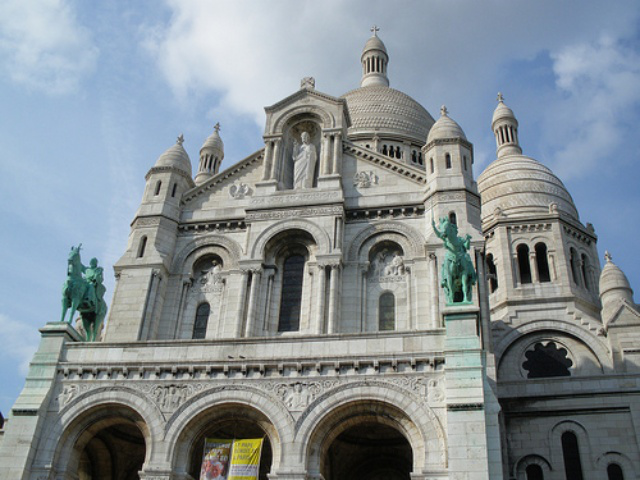

In [53]:
image = Image.open('../data/sacre_coeur_A.jpg')
print(image.size)
image

(480, 640, 3)


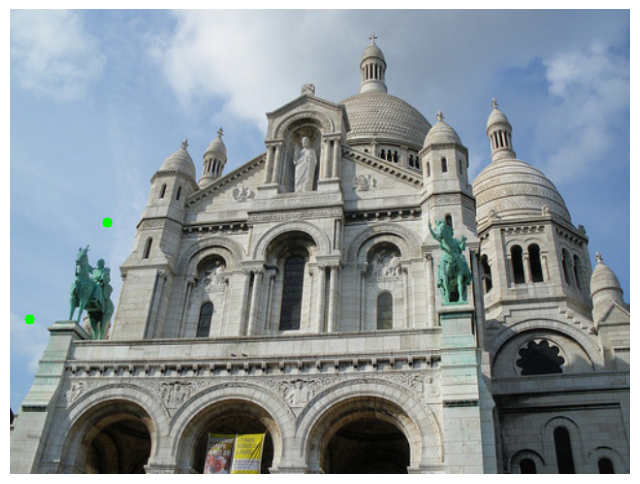

In [66]:
keypoints = [
    # (264, 203),
    (100, 220),  # width axis, height axis
    (20, 320),
]

image_np = np.array(image)
print(image_np.shape)

vis_keypoints(image_np, keypoints)

[[100.0, 20.0], [20.0, 120.0]]


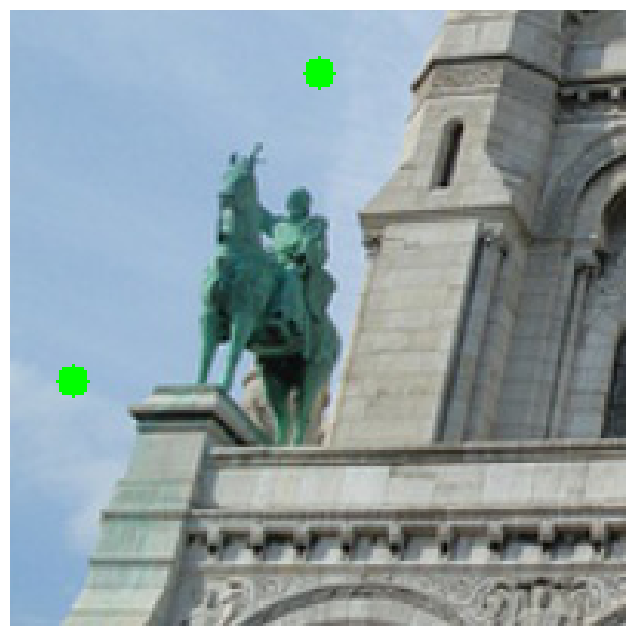

In [67]:
transform = A.Compose(
    transforms=[
        A.Crop(x_min=0, y_min=200, x_max=200, y_max=400),
    ], 
    keypoint_params=A.KeypointParams(format='xy')
)

transformed = transform(image=image_np, keypoints=keypoints)
transformed_image = transformed['image']
transformed_keypoints = transformed['keypoints']

print(transformed_keypoints)

vis_keypoints(transformed_image, transformed_keypoints)